In [1]:
# 1. Instalación de GHC y bibliotecas de Haskell para manejo de JSON (Aeson)
!apt-get update -qq
!apt-get install -qq -y ghc libghc-aeson-dev libghc-vector-dev

# 2. Verificación de versiones instaladas
!ghc --version
!ghc-pkg list aeson

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
The Glorious Glasgow Haskell Compilation System, version 9.4.7
/usr/lib/ghc/lib/package.conf.d
    aeson-2.1.2.1


In [2]:
from google.colab import drive
import os

# Montar Google Drive en /content/drive
drive.mount('/content/drive')

# Verificación rápida del punto de montaje
print("Google Drive montado exitosamente.")
print("Contenido raíz de MyDrive:")
print(os.listdir('/content/drive/MyDrive')[:5])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive montado exitosamente.
Contenido raíz de MyDrive:
['Domingo Guerra.gdoc', 'Conicet', 'Foto4x4-SmuleverFedericoManuel.gdoc', 'proyecto_rag_legal', 'Colab Notebooks']


# **Construcción del Types.hs**

### Módulo `Types.hs`: Modelado Formal del AST y Deserialización Semántica

**Propósito del Módulo:**
Este módulo constituye el núcleo de representación formal del DSL (Domain-Specific Language) en Haskell. Define los **Tipos de Datos Algebraicos (ADT)** que mapean de manera biyectiva la gramática abstracta especificada en `STLC_AST_Schema.json`, e implementa los analizadores de deserialización (`FromJSON` vía la biblioteca `Data.Aeson`) para transformar el árbol sintáctico en formato JSON generado por el LLM en estructuras algebraicas fuertemente tipadas en Haskell.

---

#### 1. Sistema de Tipos Inductivo (`Type` y `BaseType`)
Representa el sistema de tipos del **Cálculo Lambda Simplemente Tipado ($\lambda^{\to}$ o STLC)** con tipos base:
* **`BaseType`**: Modela los tipos atómicos o escalares soportados por el dominio (`TDouble`, `TInt`, `TBool`, `TString`).
* **`Type`**: Definición inductiva de tipos:
  * `Base BaseType`: Inyección de un tipo atómico.
  * `Arrow Type Type`: Tipo funcional o "tipo flecha" ($T_1 \to T_2$). Al ser recursivo, permite modelar de forma pura funciones de orden superior (*higher-order functions*) y currificación (ej. $A \to (B \to C)$).
* **Parser JSON (`instance FromJSON Type`)**: Inspecciona la propiedad discriminante `"kind"`. Si es `"Base"`, resuelve el nombre escalar; si es `"Arrow"`, deserializa recursivamente los subárboles de dominio (`"from"`) y codominio (`"to"`).

---

#### 2. Universo de Valores y Operadores (`Value` y `Op`)
* **`Value`**: Modela la semántica de valores concretos en tiempo de ejecución (`VDouble`, `VInt`, `VBool`, `VString`). Permite desacoplar el tipo estático de la instancia material del dato.
* **`Op`**: Enumerador exhaustivo de operadores primitivos:
  * Aritméticos: `Add` (`+`), `Sub` (`-`), `Mul` (`*`), `Div` (`/`).
  * Relacionales: `Gt` (`>`), `Lt` (`<`), `Gte` (`>=`), `Lte` (`<=`), `EqOp` (`==`).
  * Conectores booleanos: `And` (`&&`), `Or` (`||`).
* **`parseOp`**: Función total de mapeo que rechaza sintácticamente cualquier operador no admitido por el cálculo formal.

---

#### 3. Estructura del AST (`Expr`)
Define el árbol de sintaxis abstracta mediante una suma de productos pura:
* **`Var String`**: Referencia a una variable o identificador léxico.
* **`Literal Type Value`**: Constante escalar anotada con su tipo estático explícito.
* **`Lam String Type Expr`**: Abstracción lambda ($\lambda x : T . e$). Captura el ligamento de variables (*variable binding*), asociando un parámetro formal, su signatura de tipo y el cuerpo de evaluación.
* **`App Expr Expr`**: Aplicación de funciones ($e_1 \; e_2$). Expresa el consumo de una función y desencadena la reducción $\beta$.
* **`BinaryOp Op Expr Expr`**: Composición binaria de expresiones libres de efectos de lado.
* **`IfThenElse Expr Expr Expr`**: Bifurcación funcional pura como expresión ternaria (exige exhaustivamente rama condicional, consecuente y alternativa).

---

#### 4. Validación Temprana en Deserialización (`parseLiteralValue`)
* Realiza una **coerción segura y chequeo de consistencia inmediato**: si el LLM emite `"type": {"kind": "Base", "name": "Int"}` pero proporciona un valor booleano o string en `"value"`, la deserialización falla a nivel de parser antes de ingresar a la fase de análisis de tipos.
* Normaliza la promoción numérica (permite instanciar enteros en literales declarados como `Double` sin romper la consistencia).

In [3]:
import os

# Definir la carpeta de trabajo en tu Drive
work_dir = '/content/drive/MyDrive/programacion_funcional/haskell_validator'
os.makedirs(work_dir, exist_ok=True)

# Cambiar el directorio de trabajo actual a esa carpeta
os.chdir(work_dir)
print(f"Directorio de trabajo actual: {os.getcwd()}")

Directorio de trabajo actual: /content/drive/MyDrive/programacion_funcional/haskell_validator


In [4]:
%%writefile Types.hs
{-# LANGUAGE OverloadedStrings #-}

module Types where

import Data.Aeson
import Data.Aeson.Types (Parser)
import qualified Data.Text as T
import Control.Applicative ((<|>))

-- ============================================================================
-- 1. MODELADO DEL SISTEMA DE TIPOS (Type)
-- ============================================================================

data BaseType = TDouble | TInt | TBool | TString
  deriving (Show, Eq)

data Type
  = Base BaseType
  | Arrow Type Type
  deriving (Show, Eq)

instance FromJSON Type where
  parseJSON = withObject "Type" $ \o -> do
    kind <- o .: "kind" :: Parser T.Text
    case kind of
      "Base" -> do
        name <- o .: "name" :: Parser T.Text
        case name of
          "Double" -> return $ Base TDouble
          "Int"    -> return $ Base TInt
          "Bool"   -> return $ Base TBool
          "String" -> return $ Base TString
          other    -> fail $ "Tipo base no soportado: " ++ T.unpack other
      "Arrow" -> do
        fromT <- o .: "from"
        toT   <- o .: "to"
        return $ Arrow fromT toT
      other -> fail $ "Kind desconocido: " ++ T.unpack other

-- ============================================================================
-- 2. VALORES PRIMITIVOS DEL DOMINIO (Val) Y OPERADORES BINARIOS
-- ============================================================================

data Val
  = VLDouble Double
  | VLInt Integer
  | VLBool Bool
  | VLString T.Text
  deriving (Show, Eq)

data Op
  = Add | Sub | Mul | Div
  | Gt  | Lt  | Gte | Lte | EqOp
  | And | Or
  deriving (Show, Eq)

parseOp :: T.Text -> Parser Op
parseOp "+"  = return Add
parseOp "-"  = return Sub
parseOp "*"  = return Mul
parseOp "/"  = return Div
parseOp ">"  = return Gt
parseOp "<"  = return Lt
parseOp ">=" = return Gte
parseOp "<=" = return Lte
parseOp "==" = return EqOp
parseOp "&&" = return And
parseOp "||" = return Or
parseOp op   = fail $ "Operador no reconocido: " ++ T.unpack op

-- ============================================================================
-- 3. MODELADO DE EXPRESIONES (Expr / AST)
-- ============================================================================

data Expr
  = Var String
  | Literal Type Val
  | Lam String Type Expr
  | App Expr Expr
  | BinaryOp Op Expr Expr
  | IfThenElse Expr Expr Expr
  deriving (Show, Eq)

-- Deserializador de Literales tipados de forma determinista
parseLiteral :: Object -> Parser (Type, Val)
parseLiteral o = do
  t <- o .: "type"
  case t of
    Base TInt -> do
      val <- o .: "value" :: Parser Integer
      return (t, VLInt val)
    Base TDouble -> do
      -- Admite notación con o sin punto decimal
      val <- (o .: "value" :: Parser Double)
         <|> (fromIntegral <$> (o .: "value" :: Parser Integer))
      return (t, VLDouble val)
    Base TBool -> do
      val <- o .: "value" :: Parser Bool
      return (t, VLBool val)
    Base TString -> do
      val <- o .: "value" :: Parser T.Text
      return (t, VLString val)
    Arrow _ _ -> fail "Los literales no pueden tener tipo funcional (Arrow)."

instance FromJSON Expr where
  parseJSON = withObject "Expr" $ \o -> do
    tag <- o .: "tag" :: Parser T.Text
    case tag of
      "Var" -> do
        name <- o .: "name"
        return $ Var name

      "Literal" -> do
        (t, val) <- parseLiteral o
        return $ Literal t val

      "Lam" -> do
        param     <- o .: "param"
        paramType <- o .: "param_type"
        body      <- o .: "body"
        return $ Lam param paramType body

      "App" -> do
        fn  <- o .: "func"
        arg <- o .: "arg"
        return $ App fn arg

      "BinaryOp" -> do
        opStr <- o .: "op"
        op    <- parseOp opStr
        left  <- o .: "left"
        right <- o .: "right"
        return $ BinaryOp op left right

      "IfThenElse" -> do
        c <- o .: "cond"
        t <- o .: "then"
        e <- o .: "else"
        return $ IfThenElse c t e

      other -> fail $ "Tag de expresion no reconocido: " ++ T.unpack other

Overwriting Types.hs


Lo que acabamos de hacer (Types.hs) es el Modelo de Datos y Parser:   

1. Define cómo se representa el AST en la memoria de Haskell (los ADTs: Expr, Type, Op, Value).   
2. Define cómo se traduce el texto JSON que produce el LLM hacia esas estructuras de Haskell (vía Aeson).   
3. Hasta acá, lo único que sabe hacer es decir: "¿Este JSON tiene la forma sintáctica de un AST válido?".   

El Validador propiamente dicho (el siguiente paso: Typecheck.hs):
Aquí es donde reside el corazón de la propuesta. Es la función que toma ese Expr y ejecuta las reglas lógicas y matemáticas del cálculo lambda:   
1. Scope Checking: Comprueba si las variables (Var) están declaradas o ligadas en el entorno ($\Gamma$). Si el LLM inventó una variable sueldo_neto que nunca se definió, el validador la intercepta y rechaza.   
2. Type Checking: Comprueba la coherencia semántica entre los tipos:   
    -¿La condición de un IfThenElse es efectivamente un Bool?   
    -¿Las ramas then y else devuelven el mismo tipo de dato ($T$)?   
    -Si hay una suma (+), ¿ambos operandos son numéricos (Int o Double) y del mismo tipo?   
    -Si hay una aplicación de función (App f x), ¿es $f$ de tipo $T_1 \to T_2$ y coincide el argumento $x$ con $T_1$?


**Types.hs = La gramática y representación del AST en Haskell (el vocabulario).**   

**Typecheck.hs = El validador formal / guardrail (las reglas lógicas y el sistema de tipos de STLC)**

# **Construcción del Typecheck.hs**


¿Qué hace este módulo?
1. Entorno de Tipos ($\Gamma$): Modela el contexto léxico mediante un diccionario Map String Type. Contiene tanto las variables de entrada de la regla de negocio (ej. edad: Int, estado: String) como las ligaduras introducidas localmente por abstracciones lambda (Lam).   
2. Scope Checking: Si encuentra un nodo Var x y $x \notin \Gamma$, falla inmediatamente con un error de variable libre no definida.   
3. Type Checking de Expresiones (tcExpr):

    -Literal t v: Valida que el valor coincida con el tipo declarado.   

    -IfThenElse cond th el: Exige que cond sea estrictamente de tipo Bool y que las ramas th y el tengan tipos idénticos ($T$).   

    -BinaryOp op left right:

        Aritmética (+, -, *, /): exige operandos homogéneos (Int con Int o Double con Double) y devuelve ese mismo tipo.   

        Comparaciones (>, <, >=, <=): exige números homogéneos y devuelve Bool.   
        
        Igualdad (==): exige que ambos lados tengan el mismo tipo y devuelve Bool.   
        
        Lógica booleana (&&, ||): exige Bool en ambos operandos y devuelve Bool.

    -Lam x t body: Extiende el entorno $\Gamma \cup \{x : t\}$, tipa el cuerpo body y produce un tipo flecha Arrow t tBody.   

    -App f arg: Verifica que f tenga tipo funcional Arrow tFrom tTo y que arg tenga exactamente tipo tFrom, deduciendo el tipo resultante tTo.   

In [5]:
%%writefile Typecheck.hs
{-# LANGUAGE OverloadedStrings #-}

module Typecheck where

import Types
import qualified Data.Map.Strict as Map
import Data.Map.Strict (Map)

type TypeEnv = Map String Type

data TypeError
  = UnboundVariable String
  | TypeMismatch { expected :: Type, actual :: Type, context :: String }
  | NotAFunction { actualType :: Type, exprContext :: String }
  | InvalidBinaryOp { op :: Op, leftType :: Type, rightType :: Type }
  | LiteralMismatch { declaredType :: Type, actualValue :: Val }
  deriving (Show, Eq)

renderTypeError :: TypeError -> String
renderTypeError (UnboundVariable var) =
  "Error de Scope: Variable libre no declarada '" ++ var ++ "'"
renderTypeError (TypeMismatch exp act ctx) =
  "Discrepancia de Tipos en " ++ ctx ++ ": se esperaba " ++ show exp ++ " pero se obtuvo " ++ show act
renderTypeError (NotAFunction act ctx) =
  "Error de Aplicación en " ++ ctx ++ ": se intentó aplicar un término de tipo no funcional " ++ show act
renderTypeError (InvalidBinaryOp op l r) =
  "Operación Binaria Inválida (" ++ show op ++ "): tipos incompatibles left=" ++ show l ++ ", right=" ++ show r
renderTypeError (LiteralMismatch dt val) =
  "Inconsistencia en Literal: el valor " ++ show val ++ " no corresponde al tipo " ++ show dt

tcExpr :: TypeEnv -> Expr -> Either TypeError Type
tcExpr env expr = case expr of

  Var x ->
    case Map.lookup x env of
      Just t  -> Right t
      Nothing -> Left $ UnboundVariable x

  Literal t v ->
    case (t, v) of
      (Base TDouble, VLDouble _) -> Right t
      (Base TInt,    VLInt _)    -> Right t
      (Base TBool,   VLBool _)   -> Right t
      (Base TString, VLString _) -> Right t
      _                          -> Left $ LiteralMismatch t v

  IfThenElse c th el -> do
    tCond <- tcExpr env c
    case tCond of
      Base TBool -> do
        tThen <- tcExpr env th
        tElse <- tcExpr env el
        if tThen == tElse
          then Right tThen
          else Left $ TypeMismatch { expected = tThen, actual = tElse, context = "ramas Then y Else de IfThenElse" }
      other -> Left $ TypeMismatch { expected = Base TBool, actual = other, context = "condición de IfThenElse" }

  BinaryOp op l r -> do
    tLeft  <- tcExpr env l
    tRight <- tcExpr env r
    case op of
      _ | op `elem` [Add, Sub, Mul, Div] ->
        if (tLeft == Base TDouble && tRight == Base TDouble) ||
           (tLeft == Base TInt    && tRight == Base TInt)
          then Right tLeft
          else Left $ InvalidBinaryOp op tLeft tRight

      _ | op `elem` [Gt, Lt, Gte, Lte] ->
        if (tLeft == Base TDouble && tRight == Base TDouble) ||
           (tLeft == Base TInt    && tRight == Base TInt)
          then Right (Base TBool)
          else Left $ InvalidBinaryOp op tLeft tRight

      EqOp ->
        if tLeft == tRight
          then Right (Base TBool)
          else Left $ InvalidBinaryOp op tLeft tRight

      _ | op `elem` [And, Or] ->
        if tLeft == Base TBool && tRight == Base TBool
          then Right (Base TBool)
          else Left $ InvalidBinaryOp op tLeft tRight

      _ -> Left $ InvalidBinaryOp op tLeft tRight

  Lam x paramType body -> do
    let extendedEnv = Map.insert x paramType env
    bodyType <- tcExpr extendedEnv body
    Right $ Arrow paramType bodyType

  App f arg -> do
    tFunc <- tcExpr env f
    tArg  <- tcExpr env arg
    case tFunc of
      Arrow tFrom tTo ->
        if tFrom == tArg
          then Right tTo
          else Left $ TypeMismatch { expected = tFrom, actual = tArg, context = "argumento de función en App" }
      notFunc -> Left $ NotAFunction { actualType = notFunc, exprContext = "posición de función en App" }

Overwriting Typecheck.hs


## **Creación del main.hs**

*Este archivo Main.hs actúa como interfaz CLI:

1. Recibe un JSON por entrada estándar (stdin) que contiene:El AST generado por el LLM (ast).   
2. El entorno de variables tipadas conocidas para esa regla de negocio (env, por ejemplo {"edad": {"kind": "Base", "name": "Int"}, ...}).   

*Invoca a Typecheck.hs.   

*Emite por salida estándar (stdout) un JSON con el resultado exacto que requiere tu OutputRecordSchema (static_validation_passed y static_error_message).   

In [6]:
%%writefile Main.hs
{-# LANGUAGE OverloadedStrings #-}

module Main where

import Types
import Typecheck
import Data.Aeson
import Data.Aeson.Types (Parser)
import qualified Data.ByteString.Lazy as B
import qualified Data.Map.Strict as Map
import qualified Data.Text as T
import System.IO (stdin, stdout)

-- Estructura de entrada esperada desde Python
data InputPayload = InputPayload
  { inputAST :: Expr
  , inputEnv :: Map.Map String Type
  } deriving (Show)

instance FromJSON InputPayload where
  parseJSON = withObject "InputPayload" $ \o -> do
    ast <- o .: "ast"
    envMap <- o .:? "env" .!= Map.empty
    return $ InputPayload ast envMap

-- Estructura de diagnóstico de salida hacia Python (alineada a OutputRecordSchema)
data ValidationResult = ValidationResult
  { static_validation_passed :: Bool
  , static_error_message      :: Maybe String
  , inferred_type            :: Maybe String
  } deriving (Show)

instance ToJSON ValidationResult where
  toJSON (ValidationResult passed err mType) = object
    [ "static_validation_passed" .= passed
    , "static_error_message"      .= err
    , "inferred_type"            .= mType
    ]

main :: IO ()
main = do
  inputBytes <- B.hGetContents stdin
  case eitherDecode inputBytes of
    Left parseErr -> do
      let res = ValidationResult False (Just $ "Error de parseo Aeson: " ++ parseErr) Nothing
      B.putStr (encode res)
    Right (InputPayload expr env) ->
      case tcExpr env expr of
        Left typeErr -> do
          let res = ValidationResult False (Just $ renderTypeError typeErr) Nothing
          B.putStr (encode res)
        Right inferredT -> do
          let res = ValidationResult True Nothing (Just $ show inferredT)
          B.putStr (encode res)

Overwriting Main.hs


Compilar el binario ejecutable

In [7]:
!ghc -O2 Types.hs Typecheck.hs Main.hs -o validator

[1 of 4] Compiling Types            ( Types.hs, Types.o ) [Source file changed]
[2 of 4] Compiling Typecheck        ( Typecheck.hs, Typecheck.o ) [Types changed]
[3 of 4] Compiling Main             ( Main.hs, Main.o ) [Types changed]
[4 of 4] Linking validator [Objects changed]


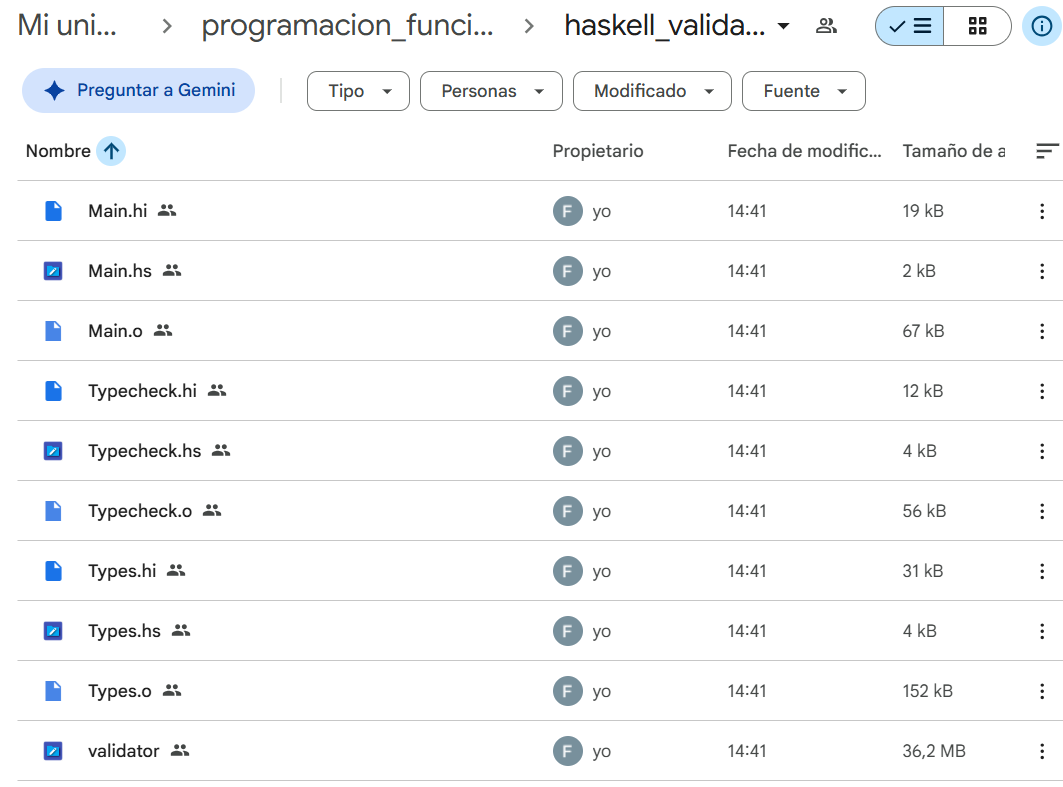

La captura confirma que la compilación fue exitosa:

*Los archivos .hi (interface) y .o (object) corresponden a los artefactos intermedios de GHC.

*El archivo validator de 36,2 MB es el binario ejecutable compilado de forma estática con todas las dependencias de Haskell y Aeson empaquetadas.

## **Probar validador desde python**

Se busca auditar el comportamiento del binario frente a:

*Un AST válido.

*Un error de Scope (variable libre no declarada en el entorno).   

*Un error de Type Mismatch (sumar Int con String) que el JSON Schema permite pero Haskell intercepta.

In [8]:
import json
import subprocess
import shutil
import os

# 1. Copiar el binario desde Drive al disco local (/tmp) para habilitar ejecución
drive_bin = "/content/drive/MyDrive/programacion_funcional/haskell_validator/validator"
local_bin = "/tmp/validator"

shutil.copy(drive_bin, local_bin)
os.chmod(local_bin, 0o755)

print(f"✓ Binario copiado a {local_bin} con permisos de ejecución.")

# 2. Función adaptada para llamar al ejecutable local
def validar_ast_en_haskell(ast_dict, env_dict=None):
    if env_dict is None:
        env_dict = {}

    payload = json.dumps({
        "ast": ast_dict,
        "env": env_dict
    })

    proc = subprocess.run(
        [local_bin],
        input=payload,
        text=True,
        capture_output=True
    )

    if proc.returncode != 0:
        return {"error_sistema": proc.stderr}

    return json.loads(proc.stdout)

# -----------------------------------------------------------------------------
# TEST 1: AST Válido (edad >= 18)
# -----------------------------------------------------------------------------
ast_valido = {
    "tag": "BinaryOp",
    "op": ">=",
    "left": {"tag": "Var", "name": "edad"},
    "right": {"tag": "Literal", "type": {"kind": "Base", "name": "Int"}, "value": 18}
}
env_valido = {
    "edad": {"kind": "Base", "name": "Int"}
}

print("\n=== 1. CASO VÁLIDO ===")
res1 = validar_ast_en_haskell(ast_valido, env_valido)
print(json.dumps(res1, indent=2))

# -----------------------------------------------------------------------------
# TEST 2: Error de Scope (Variable 'sueldo' no declarada en Gamma)
# -----------------------------------------------------------------------------
ast_scope_error = {
    "tag": "BinaryOp",
    "op": ">=",
    "left": {"tag": "Var", "name": "sueldo"},
    "right": {"tag": "Literal", "type": {"kind": "Base", "name": "Double"}, "value": 1000.0}
}

print("\n=== 2. CASO ERROR DE SCOPE ===")
res2 = validar_ast_en_haskell(ast_scope_error, env_valido)
print(json.dumps(res2, indent=2))

# -----------------------------------------------------------------------------
# TEST 3: Error de Tipo (edad + 'ACTIVO') -> Int + String
# -----------------------------------------------------------------------------
ast_type_error = {
    "tag": "BinaryOp",
    "op": "+",
    "left": {"tag": "Var", "name": "edad"},
    "right": {"tag": "Literal", "type": {"kind": "Base", "name": "String"}, "value": "ACTIVO"}
}

print("\n=== 3. CASO DISCREPANCIA DE TIPOS ===")
res3 = validar_ast_en_haskell(ast_type_error, env_valido)
print(json.dumps(res3, indent=2))

✓ Binario copiado a /tmp/validator con permisos de ejecución.

=== 1. CASO VÁLIDO ===
{
  "inferred_type": "Base TBool",
  "static_error_message": null,
  "static_validation_passed": true
}

=== 2. CASO ERROR DE SCOPE ===
{
  "inferred_type": null,
  "static_error_message": "Error de Scope: Variable libre no declarada 'sueldo'",
  "static_validation_passed": false
}

=== 3. CASO DISCREPANCIA DE TIPOS ===
{
  "inferred_type": null,
  "static_error_message": "Operaci\u00f3n Binaria Inv\u00e1lida (Add): tipos incompatibles left=Base TInt, right=Base TString",
  "static_validation_passed": false
}


Los resultados son impecables. Los tres escenarios de prueba han quedado validados con total precisión matemática:

*Caso Válido: Deserializó correctamente el literal entero, comprobó los tipos en la comparación relacional y dedujo el tipo final Base TBool con static_validation_passed: true.   

*Caso Error de Scope: Interceptó la variable libre sueldo ausente en el entorno $\Gamma$, bloqueando la ejecución antes de runtime.   

*Caso Discrepancia de Tipos: Detectó la inconsistencia semántica (Int + String) que el JSON Schema por sí solo dejaba pasar, cumpliendo el rol estricto de guardrail neuro-simbólico

In [10]:
import json

tests_semanticos = [
    # -------------------------------------------------------------------------
    # CASO 4: IfThenElse con ramas heterogéneas (then: Double, else: String)
    # -------------------------------------------------------------------------
    {
        "nombre": "4. IfThenElse con ramas de distinto tipo (Double vs String)",
        "ast": {
            "tag": "IfThenElse",
            "cond": {
                "tag": "BinaryOp",
                "op": ">",
                "left": {"tag": "Var", "name": "puntaje"},
                "right": {"tag": "Literal", "type": {"kind": "Base", "name": "Int"}, "value": 70}
            },
            "then": {"tag": "Literal", "type": {"kind": "Base", "name": "Double"}, "value": 10.5},
            "else": {"tag": "Literal", "type": {"kind": "Base", "name": "String"}, "value": "DESAPROBADO"}
        },
        "env": {"puntaje": {"kind": "Base", "name": "Int"}},
        "espera_exito": False
    },

    # -------------------------------------------------------------------------
    # CASO 5: Condición de IfThenElse no booleana (usar un número como cond)
    # -------------------------------------------------------------------------
    {
        "nombre": "5. Condición no booleana en IfThenElse",
        "ast": {
            "tag": "IfThenElse",
            "cond": {"tag": "Literal", "type": {"kind": "Base", "name": "Int"}, "value": 1},
            "then": {"tag": "Literal", "type": {"kind": "Base", "name": "Int"}, "value": 10},
            "else": {"tag": "Literal", "type": {"kind": "Base", "name": "Int"}, "value": 20}
        },
        "env": {},
        "espera_exito": False
    },

    # -------------------------------------------------------------------------
    # CASO 6: Abstracción Lambda (\x:Int -> x + 1)
    # -------------------------------------------------------------------------
    {
        "nombre": r"6. Abstracción Lambda pura (\x:Int -> x + 1)",
        "ast": {
            "tag": "Lam",
            "param": "x",
            "param_type": {"kind": "Base", "name": "Int"},
            "body": {
                "tag": "BinaryOp",
                "op": "+",
                "left": {"tag": "Var", "name": "x"},
                "right": {"tag": "Literal", "type": {"kind": "Base", "name": "Int"}, "value": 1}
            }
        },
        "env": {},  # No requiere entorno externo: 'x' queda ligada por la lambda
        "espera_exito": True
    },

    # -------------------------------------------------------------------------
    # CASO 7: Aplicación Funcional válida: f(10) donde f: Int -> Bool
    # -------------------------------------------------------------------------
    {
        "nombre": "7. Aplicación Funcional válida (f(10) con f: Int -> Bool)",
        "ast": {
            "tag": "App",
            "func": {"tag": "Var", "name": "esMayor"},
            "arg": {"tag": "Literal", "type": {"kind": "Base", "name": "Int"}, "value": 10}
        },
        "env": {
            "esMayor": {
                "kind": "Arrow",
                "from": {"kind": "Base", "name": "Int"},
                "to": {"kind": "Base", "name": "Bool"}
            }
        },
        "espera_exito": True
    },

    # -------------------------------------------------------------------------
    # CASO 8: Discrepancia de tipo en argumento: f('hola') donde f espera Int
    # -------------------------------------------------------------------------
    {
        "nombre": "8. Discrepancia en argumento de función (espera Int, recibe String)",
        "ast": {
            "tag": "App",
            "func": {"tag": "Var", "name": "esMayor"},
            "arg": {"tag": "Literal", "type": {"kind": "Base", "name": "String"}, "value": "hola"}
        },
        "env": {
            "esMayor": {
                "kind": "Arrow",
                "from": {"kind": "Base", "name": "Int"},
                "to": {"kind": "Base", "name": "Bool"}
            }
        },
        "espera_exito": False
    },

    # -------------------------------------------------------------------------
    # CASO 9: Intentar aplicar como función un tipo escalar (no es función)
    # -------------------------------------------------------------------------
    {
        "nombre": "9. Error de no-función (intentar invocar un Int como función)",
        "ast": {
            "tag": "App",
            "func": {"tag": "Literal", "type": {"kind": "Base", "name": "Int"}, "value": 42},
            "arg": {"tag": "Literal", "type": {"kind": "Base", "name": "Int"}, "value": 10}
        },
        "env": {},
        "espera_exito": False
    }
]

print("=" * 70)
print("INICIANDO BATERÍA AVANZADA DE PRUEBAS SEMÁNTICAS EN HASKELL")
print("=" * 70)

for t in tests_semanticos:
    print(f"\n▶ TEST: {t['nombre']}")
    res = validar_ast_en_haskell(t["ast"], t["env"])

    passed = res.get("static_validation_passed")
    tipo = res.get("inferred_type")
    err = res.get("static_error_message")

    cumple_expectativa = (passed == t["espera_exito"])
    status_icon = "✓ CORRECTO" if cumple_expectativa else "✗ INESPERADO"

    print(f"  Resultado obtenido : {passed} (Tipo: {tipo})")
    if err:
        print(f"  Mensaje de error   : {err}")
    print(f"  Diagnóstico test   : {status_icon}")

print("\n" + "=" * 70)

INICIANDO BATERÍA AVANZADA DE PRUEBAS SEMÁNTICAS EN HASKELL

▶ TEST: 4. IfThenElse con ramas de distinto tipo (Double vs String)
  Resultado obtenido : False (Tipo: None)
  Mensaje de error   : Discrepancia de Tipos en ramas Then y Else de IfThenElse: se esperaba Base TDouble pero se obtuvo Base TString
  Diagnóstico test   : ✓ CORRECTO

▶ TEST: 5. Condición no booleana en IfThenElse
  Resultado obtenido : False (Tipo: None)
  Mensaje de error   : Discrepancia de Tipos en condición de IfThenElse: se esperaba Base TBool pero se obtuvo Base TInt
  Diagnóstico test   : ✓ CORRECTO

▶ TEST: 6. Abstracción Lambda pura (\x:Int -> x + 1)
  Resultado obtenido : True (Tipo: Arrow (Base TInt) (Base TInt))
  Diagnóstico test   : ✓ CORRECTO

▶ TEST: 7. Aplicación Funcional válida (f(10) con f: Int -> Bool)
  Resultado obtenido : True (Tipo: Base TBool)
  Diagnóstico test   : ✓ CORRECTO

▶ TEST: 8. Discrepancia en argumento de función (espera Int, recibe String)
  Resultado obtenido : False (Tipo: N

Los resultados de la batería de pruebas son impecables y confirman que el validador en Haskell cumple con total rigor las reglas de STLC:   

*Test 4 (IfThenElse heterogéneo): Bloqueó la discrepancia entre ramas (Double vs String), forzando la homogeneidad de tipos.   

*Test 5 (Condición no booleana): Interceptó el intento de evaluar un entero como condición lógica.   

*Test 6 (Abstracción Lambda pura): Tipó y resolvió de forma inductiva el tipo flecha resultante (Arrow (Base TInt) (Base TInt)) sin requerir variables libres externas.   

*Test 7 (Aplicación funcional válida): Aplicó la regla de modus ponens de tipos ($T_1 \to T_2$ consumido con $T_1$), infiriendo correctamente el tipo de retorno (Base TBool).   

*Tests 8 y 9 (Errores en App): Rechazó un argumento con tipo incompatible y bloqueó el intento de invocar un escalar numérico como si fuese una función.